In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# 12. MODEL COMPARISON


=== Model comparison (validation set) ===
                     RMSLE           MAE        R2
XGBoost           0.213654   5789.091478  0.898118
LightGBM          0.216901   5918.883755  0.894998
Random Forest     0.224850   6159.040342  0.887161
CatBoost          0.227762   6243.317369  0.884219
Ridge (baseline)  0.527953  15986.741748  0.377892


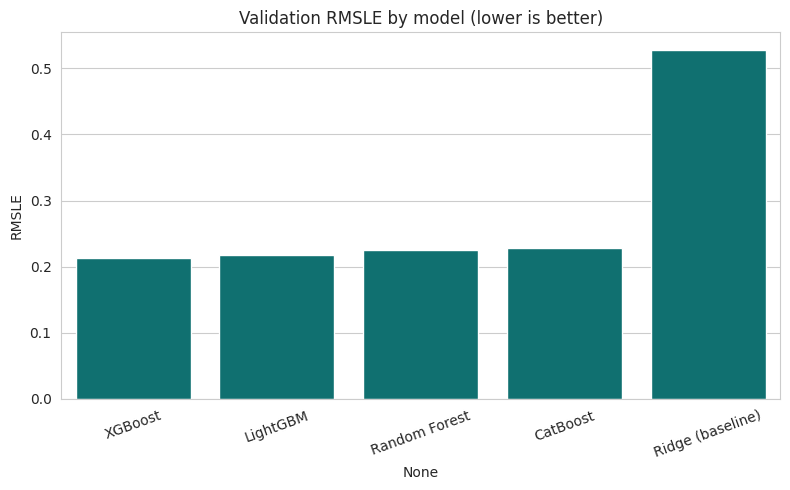


Best model on validation: XGBoost


In [21]:
# ==============================================================================
# 12. MODEL COMPARISON
# ==============================================================================
comparison_df = pd.DataFrame(results).T.sort_values("RMSLE")
print("\n=== Model comparison (validation set) ===")
print(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df["RMSLE"], color="teal")
plt.title("Validation RMSLE by model (lower is better)")
plt.ylabel("RMSLE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_model_name = comparison_df.index[0]
print(f"\nBest model on validation: {best_model_name}")


**Insight — clear ranking, clear winner**

```
                     RMSLE           MAE        R2
XGBoost           0.213654   5789.091478  0.898118
LightGBM          0.216901   5918.883755  0.894998
Random Forest     0.224850   6159.040342  0.887161
CatBoost          0.227762   6243.317369  0.884219
Ridge (baseline)  0.527953  15986.741748  0.377892
```

Two takeaways worth carrying into the tuning step: (1) all four tree models cluster within ~1.4 points of RMSLE of each other, while Ridge sits far below all of them — the *family* of model matters more than which specific boosting library is used; (2) **XGBoost wins**, so it — not the LightGBM placeholder some template scripts default to — is what Section 13 should tune. Getting this step right matters: tuning the wrong model wastes the compute budget without moving the leaderboard score.
